In [1]:
import sys

sys.path.append("../")

import scipy
import optuna

import numpy as np
import pandas as pd

from docplex.mp.model import Model
from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz
from utils import objective_scipy, ObjectiveOptuna

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simulator = AerSimulator(method="statevector", device="GPU")
estimator = BackendEstimatorV2(backend=simulator)
# estimator = StatevectorEstimator()
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
assets_data = pd.read_csv(filepath_or_buffer="../datasets/sp500_assets_close_price.csv", index_col=0)

In [4]:
assets_data

,asset_0,asset_1,asset_2,asset_3,asset_4,asset_5,asset_6,asset_7,asset_8,asset_9,...,asset_479,asset_480,asset_481,asset_482,asset_483,asset_484,asset_485,asset_486,asset_487,asset_488
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-05,83.099998,177.610001,45.306366,58.779999,167.339478,51.099705,30.020014,61.738171,21.637253,79.081268,...,600.300171,356.633820,477.410004,88.156815,1377.875732,400.141052,39.772583,148.463745,231.285416,155.642151
2025-05-06,82.870003,173.070007,44.673733,58.189999,166.615021,50.932163,29.526752,61.013409,21.490000,80.117180,...,555.485046,349.398438,473.549988,88.321411,1302.311646,403.895142,39.312119,148.040802,230.576157,147.577438
2025-05-07,82.860001,172.220001,44.333084,58.919998,168.054153,49.926926,30.306108,61.080166,21.167879,78.856499,...,557.881958,348.466766,480.540009,89.183121,1293.797119,404.451294,39.619091,148.867050,231.994659,153.603806
2025-05-08,85.440002,180.929993,44.625065,61.110001,169.385590,51.030716,30.779642,60.593811,21.370352,79.472183,...,544.694031,350.439148,484.500000,87.440315,1295.883667,402.872223,40.424908,145.827545,229.650192,159.216614
2025-05-09,76.250000,181.880005,44.381744,61.970001,168.582809,51.375656,30.483683,61.232742,21.250710,80.537407,...,524.912109,348.744293,482.899994,87.479050,1285.123535,401.958496,40.309795,146.742355,229.275864,156.833649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-28,95.430000,177.279999,38.540001,59.119999,166.490005,61.430000,17.940001,59.160000,13.919017,122.309998,...,731.770020,324.269989,483.890015,94.410004,1154.060059,480.750000,56.209999,214.229996,227.350006,116.650002
2026-04-29,99.800003,178.399994,37.349998,58.330002,162.949997,60.290001,16.900000,57.599998,13.880000,126.779999,...,686.359985,317.850006,481.220001,93.510002,1142.739990,479.369995,56.169998,212.089996,230.309998,113.830002
2026-04-30,102.980003,176.009995,38.040001,60.259998,163.929993,61.080002,17.580000,58.459999,14.350000,124.199997,...,707.059998,321.609985,482.600006,96.699997,1159.979980,492.540009,56.660000,217.339996,232.550003,114.970001


In [4]:
tickers = np.random.choice(assets_data.columns, size=10, replace=False)

In [5]:
assets_close_price = assets_data[tickers]

In [6]:
assets_pct_change = assets_close_price.pct_change().dropna()

In [7]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [8]:
q = 0.5
b = 3
return_risk_free = 0.0375
weights_array = np.array([1/b for _ in range(len(tickers))])

## Equality constraint

In [9]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() == b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 - 0.040971 x(0) - 0.024918 x(1) + 0.027840 x(2) - 0.012723 x(3)
 + 0.017637 x(4) - 0.028616 x(5) + 0.003012 x(6) - 0.081344 x(7)
 + 0.028696 x(8) + 0.016483 x(9) [ 0.000245 x(0)^2 + 0.000132 x(0)*x(1)
 - 0.000058 x(0)*x(2) + 0.000032 x(0)*x(3) + 0.000147 x(0)*x(4)
 + 0.000302 x(0)*x(5) + 0.000138 x(0)*x(6) + 0.000122 x(0)*x(7)
 + 0.000087 x(0)*x(8) + 0.000099 x(0)*x(9) + 0.000213 x(1)^2
 - 0.000023 x(1)*x(2) + 0.000065 x(1)*x(3) + 0.000054 x(1)*x(4)
 + 0.000167 x(1)*x(5) + 0.000115 x(1)*x(6) - 0.000013 x(1)*x(7)
 + 0.000005 x(1)*x(8) + 0.000113 x(1)*x(9) + 0.000383 x(2)^2
 - 0.000010 x(2)*x(3) - 0.000030 x(2)*x(4) - 0.000127 x(2)*x(5)
 - 0.000005 x(2)*x(6) + 0.000083 x(2)*x(7) + 0.000126 x(2)*x(8)
 

In [10]:
result = model.solve()

In [11]:
result.objective_value

-0.11195577546691798

In [12]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [13]:
result_array

array([1., 0., 0., 0., 0., 1., 0., 1., 0., 0.])

In [14]:
target = result_array.astype(int)
target = ""
for item in result_array.astype(int):
    target += str(item)

In [15]:
target = np.str_(target[::-1])

In [16]:
target

np.str_('0010100001')

In [17]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.0002454573554112108*x(0)^2 + 0.0001322238930729673*x(0)*x(1)
  - 5.764015906500702e-05*x(0)*x(2) + 3.1814776012444615e-05*x(0)*x(3)
  + 0.0001471246932575373*x(0)*x(4) + 0.00030221697500068664*x(0)*x(5)
  + 0.00013829203568128557*x(0)*x(6) + 0.0001222768168356127*x(0)*x(7)
  + 8.717274030472299e-05*x(0)*x(8) + 9.853921647797956e-05*x(0)*x(9)
  + 0.00021348270447141079*x(1)^2 - 2.2798368050625134e-05*x(1)*x(2)
  + 6.512778219784881e-05*x(1)*x(3) + 5.4224160091448807e-05*x(1)*x(4)
  + 0.00016734996788771503*x(1)*x(5) + 0.0001148821989129848*x(1)*x(6)
  - 1.2928008520753529e-05*x(1)*x(7) + 5.398553891373881e-06*x(1)*x(8)
  + 0.00011311354830271782*x(1)*x(9) + 0.0003829489157160335*x(2)^2
  - 9.7197490685343e-06*x(2)*x(3) - 2.965544320693617e-05*x(2)*x(4)
  - 0.00012713066049567225*x(2)*x(5) - 5.207561325768226e-06*x(2)*x(6)
  + 8.250614367012076e-05*x(2)*x(7) + 0.00012560439366001824*x(2)*x(8)
  + 4.944098928520239e-05*x(2)*

In [18]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.0002454573564112108*x(0)^2 + 0.0001322238950729673*x(0)*x(1)
  - 5.764015706500702e-05*x(0)*x(2) + 3.1814778012444614e-05*x(0)*x(3)
  + 0.0001471246952575373*x(0)*x(4) + 0.00030221697700068663*x(0)*x(5)
  + 0.00013829203768128557*x(0)*x(6) + 0.0001222768188356127*x(0)*x(7)
  + 8.717274230472299e-05*x(0)*x(8) + 9.853921847797956e-05*x(0)*x(9)
  + 0.00021348270547141078*x(1)^2 - 2.2798366050625135e-05*x(1)*x(2)
  + 6.512778419784882e-05*x(1)*x(3) + 5.4224162091448805e-05*x(1)*x(4)
  + 0.00016734996988771502*x(1)*x(5) + 0.0001148822009129848*x(1)*x(6)
  - 1.2928006520753529e-05*x(1)*x(7) + 5.398555891373881e-06*x(1)*x(8)
  + 0.00011311355030271782*x(1)*x(9) + 0.0003829489167160335*x(2)^2
  - 9.7197470685343e-06*x(2)*x(3) - 2.9655441206936173e-05*x(2)*x(4)
  - 0.00012713065849567225*x(2)*x(5) - 5.207559325768226e-06*x(2)*x(6)
  + 8.250614567012077e-05*x(2)*x(7) + 0.00012560439566001823*x(2)*x(8)
  + 4.944099128520239e-05*x(2)*x(9) + 0.00012384242321992938*x(3)^

In [19]:
ising, offset = qubo.to_ising()

In [20]:
ising

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII', 'IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIZIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIZIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIZIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IIIIZZIIII', 'IIIZIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII'],
              coeffs=[ 2.01124144e-02+0.j,  1.21981539e-02+0.j, -1.41130156e-02+0.j,
  6.19537892e-03+0.j, -9.10347232e-03+0.j,  1.38158668e-02+0.j,
 -1.82227800e-03+0.j,  4.03656119e-02+0.j, -1.46531423e-02+0.j,
 

In [21]:
offset

np.float64(-0.007699268396935537)

In [22]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=b, measurement=False)

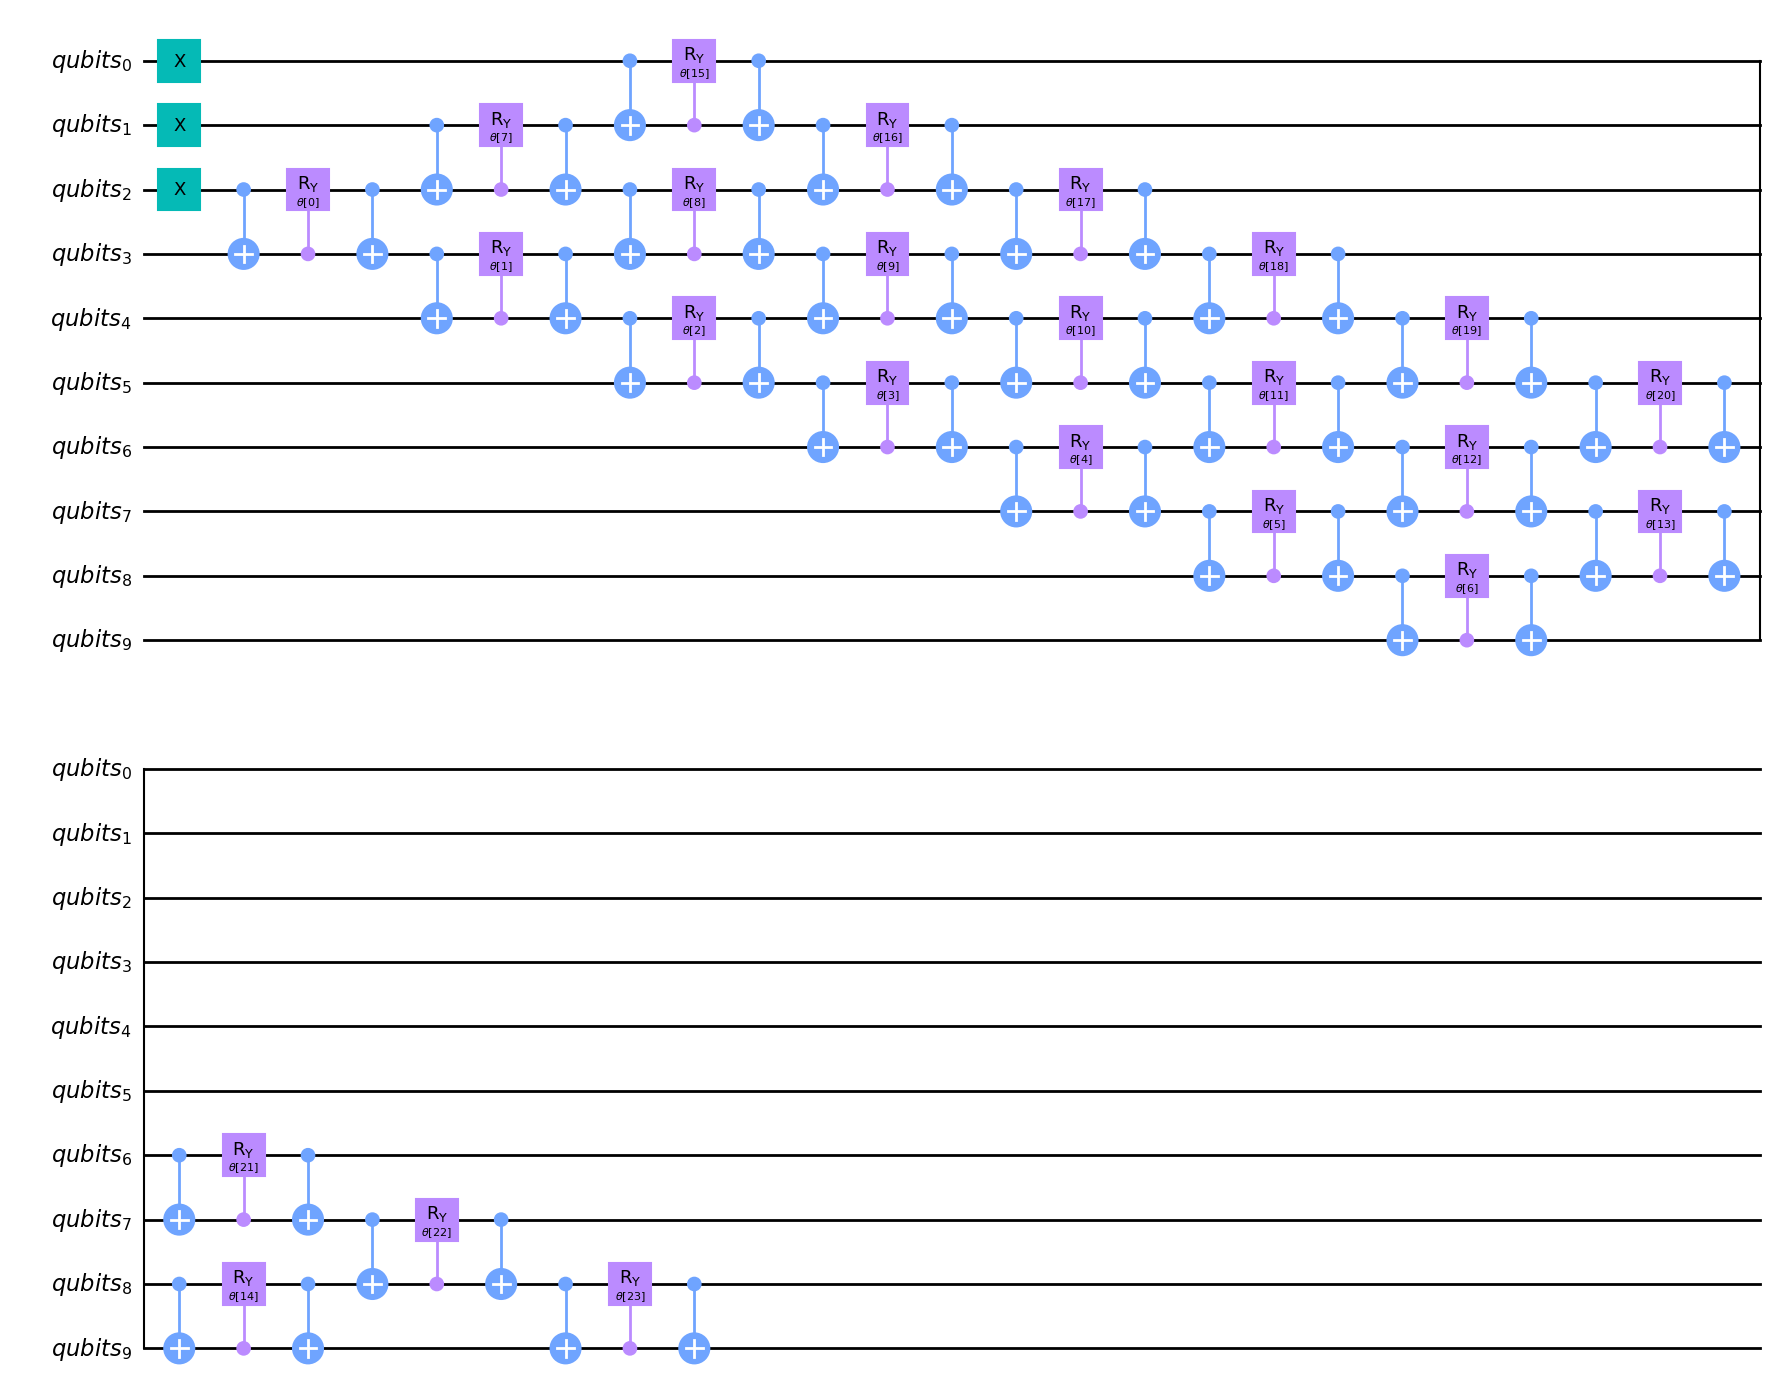

In [23]:
qc.draw(output="mpl", style="clifford")

In [29]:
x0 = 2*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 2*np.pi) for _ in range(x0.shape[0])]
callback = []
result = scipy.optimize.minimize(
    fun=objective_scipy, 
    x0=x0, 
    method="COBYLA", 
    bounds=bounds, 
    args=(estimator, qc, ising, offset, callback),
    options=dict(maxiter=1000)
)

In [30]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.10843975237173954
       x: [ 2.799e+00  3.817e+00 ...  2.051e+00  5.716e+00]
    nfev: 244
   maxcv: 0.0

In [31]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

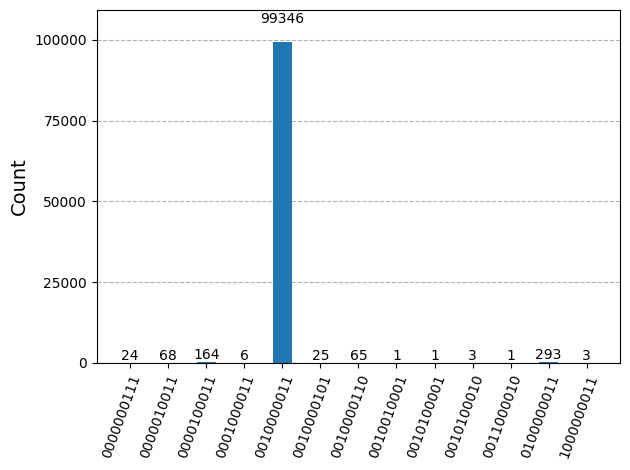

In [32]:
counts = simulator.run(circuits=ansatz, shots=100000).result().get_counts()
plot_histogram(data=counts)

In [30]:
callback = []
objective_optuna = ObjectiveOptuna(qc=qc, estimator=estimator, ising=ising, offset=offset, callback=callback)

In [31]:
x0_dict = {f"x[{i}]": value for i, value in enumerate(x0)}

In [32]:
sampler = optuna.samplers.CmaEsSampler(x0=x0_dict, use_separable_cma=True)
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``use_separable_cma`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-07 18:04:12,854] A new study created in memory with name: no-name-a998dde2-d422-49ad-a1f4-f7ce5413531e
[I 2026-05-07 18:04:12,901] Trial 0 finished with value: 0.034833589062577254 and parameters: {'x[0]': 4.693524242894397, 'x[1]': 3.5209821543370627, 'x[2]': 1.4175406057324027, 'x[3]': 2.607113367108286, 'x[4]': 3.043948580288392, 'x[5]': 5.992306107339107, 'x[6]': 1.380327597020019, 'x[7]': 2.7636367228294474, 'x[8]': 0.2520917254283728, 'x[9]': 1.7753013534691289, 'x[10]': 1.5180449518556443, 'x[11]': 4.405125886712274, 'x[12]': 4.170176623224066, 'x[13]': 0.4360353266170933, 'x[14]': 3.914234284029702, 'x[15]': 0.8338538700798062, 'x[16]': 4.383162631584478, 'x[17]': 2.111457551124808, 'x[18]': 4.4904807605232335, 'x

In [33]:
study.best_value

-0.09976103333718955

In [34]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

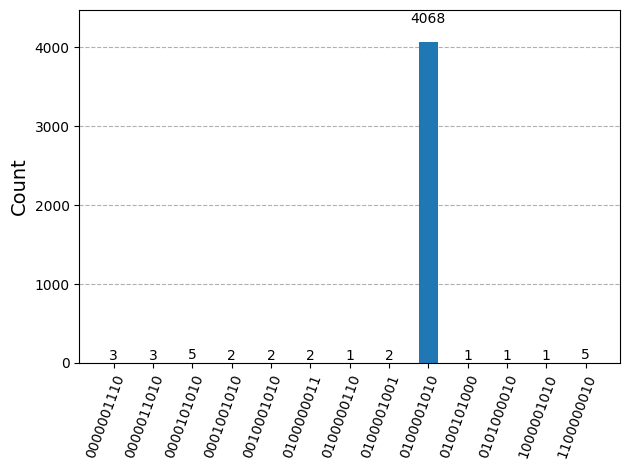

In [35]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

## Inequality constraint

In [35]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 0.108582 x(0) - 0.079497 x(1) - 0.024387 x(2) - 0.071087 x(3) - 0.020805 x(4)
 + 0.012366 x(5) - 0.030612 x(6) - 0.043762 x(7) - 0.086089 x(8)
 + 0.003756 x(9) [ 0.000826 x(0)^2 + 0.000488 x(0)*x(1) + 0.000027 x(0)*x(2)
 + 0.000292 x(0)*x(3) - 0.000007 x(0)*x(4) + 0.000390 x(0)*x(5)
 + 0.000288 x(0)*x(6) + 0.000039 x(0)*x(7) + 0.000511 x(0)*x(8)
 + 0.000200 x(0)*x(9) + 0.000761 x(1)^2 + 0.000095 x(1)*x(2)
 + 0.000293 x(1)*x(3) - 0.000032 x(1)*x(4) + 0.000471 x(1)*x(5)
 + 0.000114 x(1)*x(6) + 0.000044 x(1)*x(7) + 0.000448 x(1)*x(8)
 + 0.000223 x(1)*x(9) + 0.000445 x(2)^2 + 0.000128 x(2)*x(3)
 + 0.000090 x(2)*x(4) + 0.000175 x(2)*x(5) + 0.000121 x(2)*x(6)
 + 0.000054 x(2)*x(7) - 0.000146 x(2)*x(8) + 0

In [36]:
result = model.solve()

In [37]:
result.objective_value

-0.19653031078316394

In [38]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [39]:
result_array

array([0., 1., 0., 1., 0., 0., 0., 0., 1., 0.])

In [40]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
# model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 0.108582 x(0) - 0.079497 x(1) - 0.024387 x(2) - 0.071087 x(3) - 0.020805 x(4)
 + 0.012366 x(5) - 0.030612 x(6) - 0.043762 x(7) - 0.086089 x(8)
 + 0.003756 x(9) [ 0.000826 x(0)^2 + 0.000488 x(0)*x(1) + 0.000027 x(0)*x(2)
 + 0.000292 x(0)*x(3) - 0.000007 x(0)*x(4) + 0.000390 x(0)*x(5)
 + 0.000288 x(0)*x(6) + 0.000039 x(0)*x(7) + 0.000511 x(0)*x(8)
 + 0.000200 x(0)*x(9) + 0.000761 x(1)^2 + 0.000095 x(1)*x(2)
 + 0.000293 x(1)*x(3) - 0.000032 x(1)*x(4) + 0.000471 x(1)*x(5)
 + 0.000114 x(1)*x(6) + 0.000044 x(1)*x(7) + 0.000448 x(1)*x(8)
 + 0.000223 x(1)*x(9) + 0.000445 x(2)^2 + 0.000128 x(2)*x(3)
 + 0.000090 x(2)*x(4) + 0.000175 x(2)*x(5) + 0.000121 x(2)*x(6)
 + 0.000054 x(2)*x(7) - 0.000146 x(2)*x(8) + 0

In [41]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.0008260450680741*x(0)^2 + 0.0004883909624921235*x(0)*x(1)
  + 2.7440719292203312e-05*x(0)*x(2) + 0.0002915447000921991*x(0)*x(3)
  - 6.691721427039918e-06*x(0)*x(4) + 0.00038982184815862693*x(0)*x(5)
  + 0.00028752474279099076*x(0)*x(6) + 3.874807966130887e-05*x(0)*x(7)
  + 0.0005113804003800215*x(0)*x(8) + 0.00020006324271551828*x(0)*x(9)
  + 0.0007608521975135853*x(1)^2 + 9.547937350181738e-05*x(1)*x(2)
  + 0.00029266063335727627*x(1)*x(3) - 3.210905705700868e-05*x(1)*x(4)
  + 0.00047113280520200845*x(1)*x(5) + 0.00011418474487782736*x(1)*x(6)
  + 4.439460939209242e-05*x(1)*x(7) + 0.00044820221160104265*x(1)*x(8)
  + 0.00022345710846117714*x(1)*x(9) + 0.00044509845004117804*x(2)^2
  + 0.00012761377507174534*x(2)*x(3) + 8.952591443830402e-05*x(2)*x(4)
  + 0.0001750521873239981*x(2)*x(5) + 0.00012129019201046415*x(2)*x(6)
  + 5.4109319020486684e-05*x(2)*x(7) - 0.0001461460429295524*x(2)*x(8)
  + 4.821832356950148e-05*x(2)

In [42]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.0008260450680741*x(0)^2 + 0.0004883909624921235*x(0)*x(1)
  + 2.7440719292203312e-05*x(0)*x(2) + 0.0002915447000921991*x(0)*x(3)
  - 6.691721427039918e-06*x(0)*x(4) + 0.00038982184815862693*x(0)*x(5)
  + 0.00028752474279099076*x(0)*x(6) + 3.874807966130887e-05*x(0)*x(7)
  + 0.0005113804003800215*x(0)*x(8) + 0.00020006324271551828*x(0)*x(9)
  + 0.0007608521975135853*x(1)^2 + 9.547937350181738e-05*x(1)*x(2)
  + 0.00029266063335727627*x(1)*x(3) - 3.210905705700868e-05*x(1)*x(4)
  + 0.00047113280520200845*x(1)*x(5) + 0.00011418474487782736*x(1)*x(6)
  + 4.439460939209242e-05*x(1)*x(7) + 0.00044820221160104265*x(1)*x(8)
  + 0.00022345710846117714*x(1)*x(9) + 0.00044509845004117804*x(2)^2
  + 0.00012761377507174534*x(2)*x(3) + 8.952591443830402e-05*x(2)*x(4)
  + 0.0001750521873239981*x(2)*x(5) + 0.00012129019201046415*x(2)*x(6)
  + 5.4109319020486684e-05*x(2)*x(7) - 0.0001461460429295524*x(2)*x(8)
  + 4.821832356950148e-05*x(2)*x(9) + 0.00017433651290436837*x(3)^

In [43]:
ising, offset = qubo.to_ising()

In [44]:
identity = SparsePauliOp(data="II", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

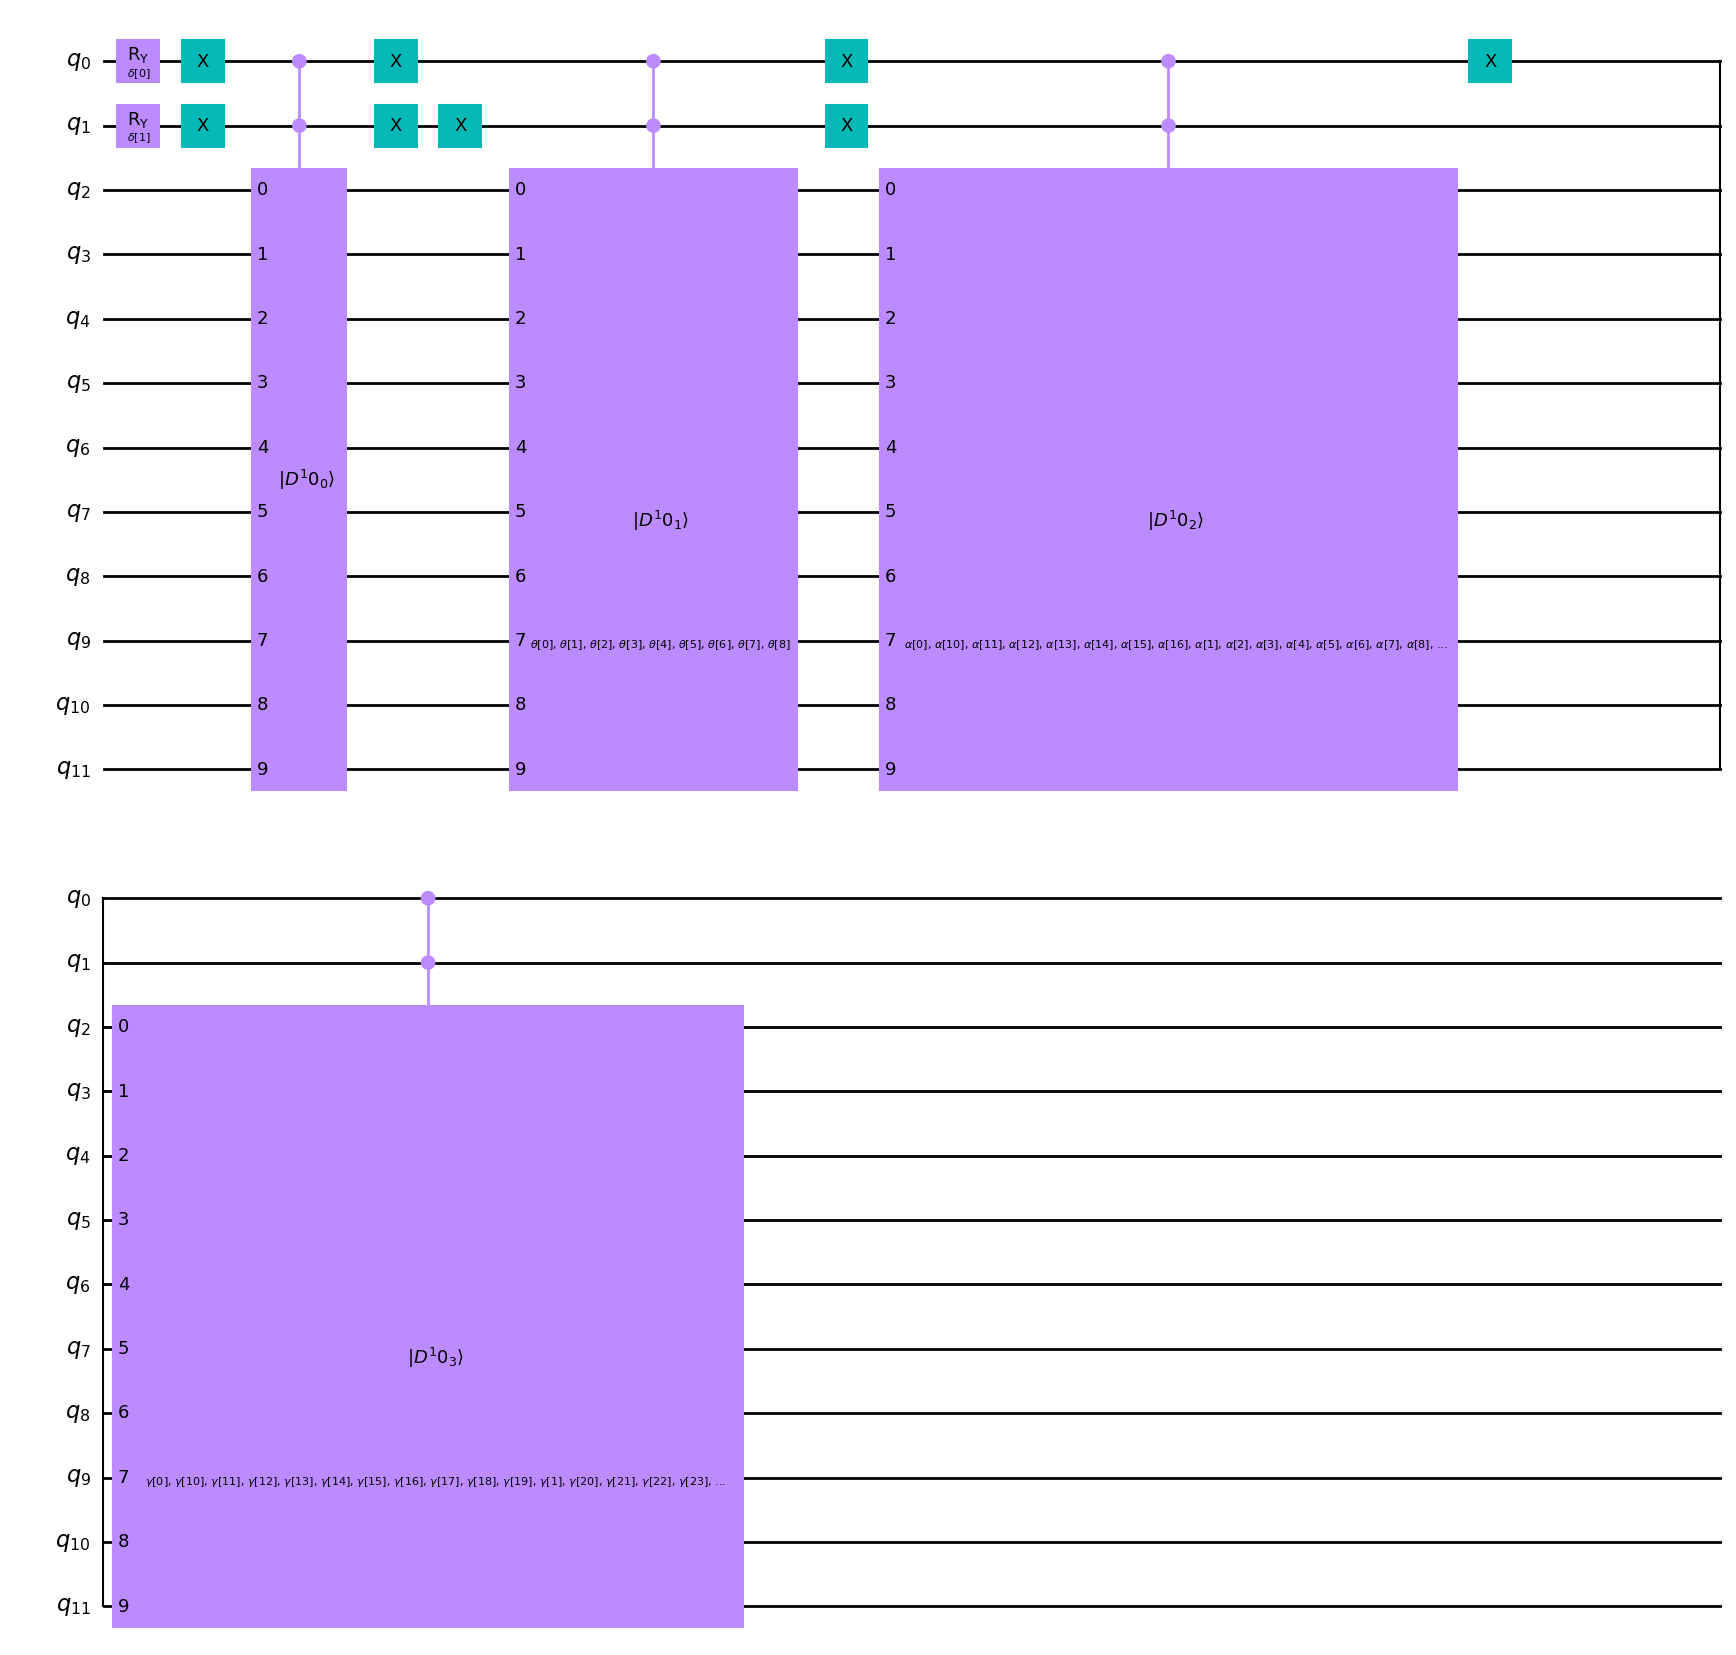

In [45]:
qubits = QuantumRegister(size=ising_expanded.num_qubits, name="q")
params_vec = ParameterVector(name=r"$\delta$", length=ising_expanded.num_qubits-ising.num_qubits)

qc = QuantumCircuit(qubits)
for idx, param in enumerate(params_vec):
    qc.ry(theta=param, qubit=qubits[idx])

params_names = {0: "", 1: "theta", 2: "alpha", 3: "gamma"}

for k in range(4):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=k, measurement=False, param_name=params_names[k])
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{len(tickers)}_{k} \rangle$").control(2)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])

qc.draw(output="mpl", style="clifford")

In [46]:
tqc = pm.run(qc)

In [47]:
x0 = 2*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 2*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyqa", bounds=bounds, args=(estimator, tqc, ising_expanded, offset))

In [48]:
result

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -0.15524869773860717
       x: [ 1.989e+00  5.438e+00 ...  4.540e-01  2.273e+00]
     nit: 521
   maxcv: 0.0
    nfev: 1052

In [49]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

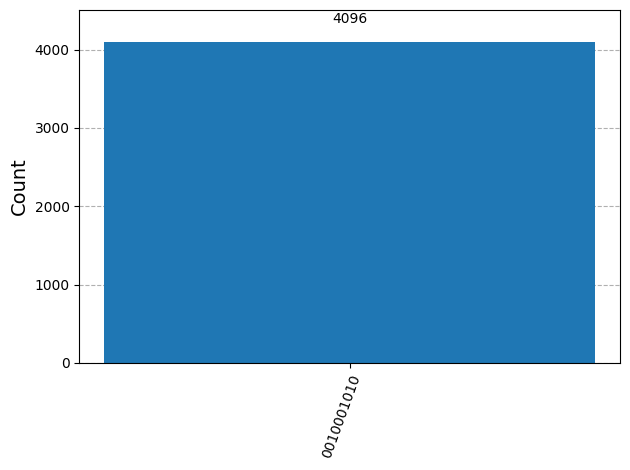

In [50]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [51]:
objective_optuna = ObjectiveOptuna(qc=tqc, estimator=estimator, ising=ising_expanded, offset=offset)

In [52]:
x0_dict = {f"x[{i}]": value for i, value in enumerate(x0)}

In [53]:
sampler = optuna.samplers.CmaEsSampler(x0=x0_dict, use_separable_cma=True)
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``use_separable_cma`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-07 17:22:34,228] A new study created in memory with name: no-name-f9ee4dd2-ca1f-47b0-bac1-6dbf328272ab
[I 2026-05-07 17:22:34,399] Trial 0 finished with value: 0.0559256224141501 and parameters: {'x[0]': 5.426830759054934, 'x[1]': 3.8159983700130646, 'x[2]': 3.163895621834948, 'x[3]': 5.995455968763389, 'x[4]': 1.9958262057838356, 'x[5]': 4.1420044875703965, 'x[6]': 0.05846042110681314, 'x[7]': 0.39247176201991707, 'x[8]': 5.2024044808660035, 'x[9]': 4.555727185374311, 'x[10]': 2.1510110578512602, 'x[11]': 5.115802204798711, 'x[12]': 1.6917389755638828, 'x[13]': 3.4746643019825334, 'x[14]': 4.242454024521481, 'x[15]': 1.0025147655686188, 'x[16]': 3.098146843174876, 'x[17]': 1.8333495522455656, 'x[18]': 3.941828799675826, 

In [54]:
study.best_value

-0.1904368913451934

In [55]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

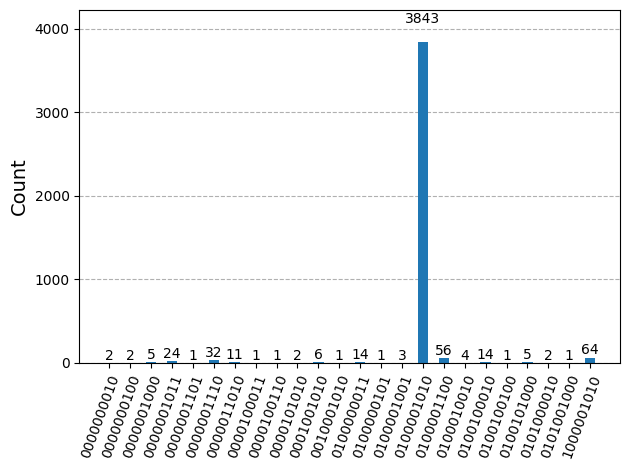

In [56]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)